# CNN vs SVM out-of-domain

Clean seed 42 as the screenshot run, seeds 42–46 for spread. Same CQT rows as the paired `cnn-latest` / `svm-latest` splits. Vivo is omitted. Recorded OOD plus eval-only overlays. Nothing is retrained here; tables read the existing result CSVs.

In [1]:
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

_CANDIDATES = [
    Path(".").resolve(),
    Path("/home/seya/code/chord-detection/training/notebooks/cnn-latest"),
    Path("training/notebooks/cnn-latest").resolve(),
]
HERE = next(p for p in _CANDIDATES if (p / "results" / "ood_seeds.csv").is_file())
CNN = HERE / "results"
SVM = HERE.parent / "svm-latest" / "results"

SEED = 42
VARIANT = "clean"
OOD = ["flow", "flow-2", "thinkpad", "thinkpad-2"]
LABEL = {"flow": "A1", "flow-2": "A2", "thinkpad": "B1", "thinkpad-2": "B2"}
NAVY = "#1f4e79"
ACCENT = "#c8791e"
METRIC_MAP = {
    "accuracy": "accuracy",
    "precision": "macro_precision",
    "recall": "macro_recall",
    "f1-score": "macro_f1",
}

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 13,
    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "legend.fontsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.frameon": False,
    "figure.dpi": 110,
})

assert (CNN / "ood_seeds.csv").is_file(), CNN
assert (SVM / "ood_seeds.csv").is_file(), SVM


def load_ood(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df = df[(df.variant == VARIANT) & (df.dataset.isin(OOD))].copy()
    df["evaluation"] = df.dataset.map(LABEL)
    return df


cnn = load_ood(CNN / "ood_seeds.csv")
svm = load_ood(SVM / "ood_seeds.csv")

display(pd.DataFrame(
    [
        {"key": "cnn", "value": str(CNN)},
        {"key": "svm", "value": str(SVM)},
        {"key": "run", "value": f"{VARIANT} seed {SEED}"},
        {"key": "ood", "value": ", ".join(f"{k}={v}" for k, v in LABEL.items())},
    ]
))

,key,value
0,cnn,/home/seya/code/chord-detection/training/noteb...
1,svm,/home/seya/code/chord-detection/training/noteb...
2,run,clean seed 42
3,ood,"flow=A1, flow-2=A2, thinkpad=B1, thinkpad-2=B2"


## Seed 42

Paired accuracy, macro precision, recall, and F1. Δ is CNN − SVM.

In [2]:
def seed_table(metric_col: str) -> pd.DataFrame:
    c = cnn.loc[cnn.seed == SEED].set_index("dataset")[metric_col]
    s = svm.loc[svm.seed == SEED].set_index("dataset")[metric_col]
    rows = []
    for ds in OOD:
        rows.append(
            {
                "evaluation": LABEL[ds],
                "CNN": float(c[ds]),
                "SVM": float(s[ds]),
                "Δ": float(c[ds] - s[ds]),
            }
        )
    return pd.DataFrame(rows)


for title, col in METRIC_MAP.items():
    display(Markdown(f"**{title}**"))
    display(seed_table(col).round(4))

**accuracy**

,evaluation,CNN,SVM,Δ
0,A1,0.8292,0.9931,-0.1639
1,A2,0.7111,0.6979,0.0132
2,B1,0.9618,0.7889,0.1729
3,B2,0.7382,0.4271,0.3111


**precision**

,evaluation,CNN,SVM,Δ
0,A1,0.8533,0.9936,-0.1403
1,A2,0.6709,0.7500,-0.0791
2,B1,0.9734,0.9006,0.0728
3,B2,0.7227,0.6770,0.0458


**recall**

,evaluation,CNN,SVM,Δ
0,A1,0.8292,0.9931,-0.1639
1,A2,0.7111,0.6979,0.0132
2,B1,0.9618,0.7889,0.1729
3,B2,0.7382,0.4271,0.3111


**f1-score**

,evaluation,CNN,SVM,Δ
0,A1,0.8164,0.9931,-0.1767
1,A2,0.6555,0.6708,-0.0153
2,B1,0.9609,0.7989,0.1620
3,B2,0.6877,0.4166,0.2711


## Seeds 42–46

Mean and std over the five paired splits. Δ mean is the mean of CNN − SVM on each seed, not the difference of the two means (they match).

In [3]:
def seed_spread(metric_col: str) -> pd.DataFrame:
    rows = []
    for ds in OOD:
        c = cnn.loc[cnn.dataset == ds].set_index("seed")[metric_col]
        s = svm.loc[svm.dataset == ds].set_index("seed")[metric_col]
        delta = (c - s).reindex(c.index)
        rows.append(
            {
                "evaluation": LABEL[ds],
                "CNN mean": float(c.mean()),
                "CNN std": float(c.std(ddof=1)),
                "SVM mean": float(s.mean()),
                "SVM std": float(s.std(ddof=1)),
                "Δ mean": float(delta.mean()),
                "Δ std": float(delta.std(ddof=1)),
            }
        )
    return pd.DataFrame(rows)


for title, col in METRIC_MAP.items():
    display(Markdown(f"**{title}**"))
    display(seed_spread(col).round(4))

**accuracy**

,evaluation,CNN mean,CNN std,SVM mean,SVM std,Δ mean,Δ std
0,A1,0.9385,0.0739,0.9814,0.0077,-0.0429,0.0774
1,A2,0.8742,0.0965,0.6804,0.0475,0.1938,0.1026
2,B1,0.9839,0.0208,0.7147,0.0593,0.2692,0.0671
3,B2,0.8649,0.0795,0.4185,0.0515,0.4464,0.0796


**precision**

,evaluation,CNN mean,CNN std,SVM mean,SVM std,Δ mean,Δ std
0,A1,0.9441,0.0659,0.9853,0.0053,-0.0413,0.0681
1,A2,0.8802,0.1202,0.7492,0.0197,0.1310,0.1225
2,B1,0.9892,0.0136,0.8607,0.0319,0.1285,0.0356
3,B2,0.8757,0.0905,0.5695,0.0998,0.3063,0.1568


**recall**

,evaluation,CNN mean,CNN std,SVM mean,SVM std,Δ mean,Δ std
0,A1,0.9385,0.0739,0.9814,0.0077,-0.0429,0.0774
1,A2,0.8742,0.0965,0.6804,0.0475,0.1938,0.1026
2,B1,0.9839,0.0208,0.7147,0.0593,0.2692,0.0671
3,B2,0.8649,0.0795,0.4185,0.0515,0.4464,0.0796


**f1-score**

,evaluation,CNN mean,CNN std,SVM mean,SVM std,Δ mean,Δ std
0,A1,0.9305,0.0828,0.9818,0.0074,-0.0513,0.0856
1,A2,0.8528,0.1162,0.6573,0.0382,0.1955,0.1181
2,B1,0.9820,0.0236,0.7246,0.0570,0.2574,0.0656
3,B2,0.8427,0.0960,0.4095,0.0569,0.4332,0.0953


## Accuracy, precision, recall, and F1

Seed 42 grouped bars, then five-seed means with one-std error bars. Δ is CNN − SVM.


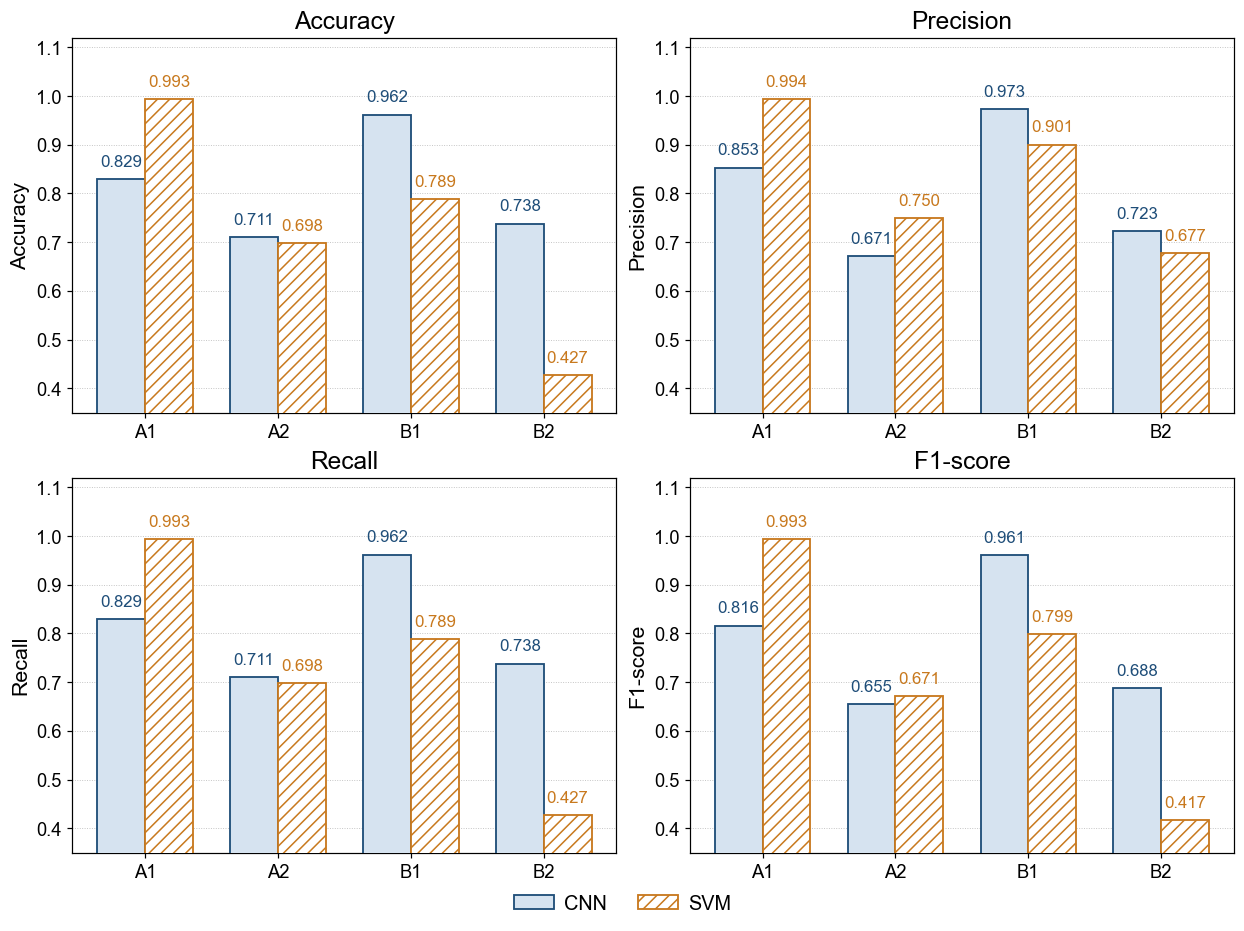

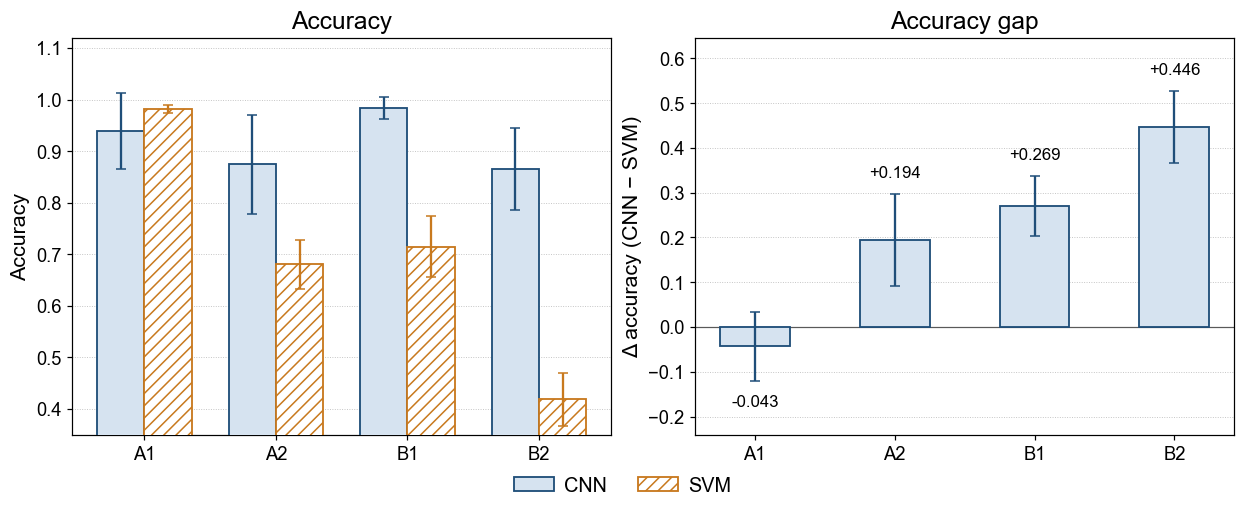

In [4]:
evals = [LABEL[ds] for ds in OOD]
x = np.arange(len(OOD))
width = 0.36
FILL = "#d6e3f0"
bar_kw = dict(linewidth=1.2, zorder=3)


def grouped_bars(ax, cnn_vals, svm_vals, ylabel):
    ax.bar(
        x - width / 2, cnn_vals, width,
        facecolor=FILL, edgecolor=NAVY, label="CNN", **bar_kw,
    )
    ax.bar(
        x + width / 2, svm_vals, width,
        facecolor="white", edgecolor=ACCENT, hatch="///", label="SVM", **bar_kw,
    )
    ax.set_xticks(x, evals)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0.35, 1.12)
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle=":", linewidth=0.6, color="0.75")
    for xi, cv, sv in zip(x, cnn_vals, svm_vals):
        ax.text(xi - width / 2, cv + 0.02, f"{cv:.3f}", ha="center", va="bottom",
                fontsize=11, color=NAVY)
        ax.text(xi + width / 2, sv + 0.02, f"{sv:.3f}", ha="center", va="bottom",
                fontsize=11, color=ACCENT)


acc42 = seed_table("accuracy")
prec42 = seed_table("macro_precision")
rec42 = seed_table("macro_recall")
f142 = seed_table("macro_f1")
fig, axes = plt.subplots(2, 2, figsize=(11.2, 8.4), layout="constrained")
grouped_bars(axes[0, 0], acc42["CNN"], acc42["SVM"], "Accuracy")
grouped_bars(axes[0, 1], prec42["CNN"], prec42["SVM"], "Precision")
grouped_bars(axes[1, 0], rec42["CNN"], rec42["SVM"], "Recall")
grouped_bars(axes[1, 1], f142["CNN"], f142["SVM"], "F1-score")
axes[0, 0].set_title("Accuracy")
axes[0, 1].set_title("Precision")
axes[1, 0].set_title("Recall")
axes[1, 1].set_title("F1-score")
fig.legend(
    handles=[
        plt.Rectangle((0, 0), 1, 1, facecolor=FILL, edgecolor=NAVY, linewidth=1.2),
        plt.Rectangle((0, 0), 1, 1, facecolor="white", edgecolor=ACCENT, linewidth=1.2, hatch="///"),
    ],
    labels=["CNN", "SVM"],
    loc="outside lower center", ncol=2, frameon=False,
    columnspacing=1.6, handletextpad=0.5,
)
plt.show()

acc = seed_spread("accuracy")
fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.6), layout="constrained")
axes[0].bar(
    x - width / 2, acc["CNN mean"], width, yerr=acc["CNN std"], capsize=3,
    facecolor=FILL, edgecolor=NAVY, ecolor=NAVY, **bar_kw,
)
axes[0].bar(
    x + width / 2, acc["SVM mean"], width, yerr=acc["SVM std"], capsize=3,
    facecolor="white", edgecolor=ACCENT, hatch="///", ecolor=ACCENT, **bar_kw,
)
axes[0].set_xticks(x, evals)
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0.35, 1.12)
axes[0].set_title("Accuracy")

axes[1].bar(
    x, acc["Δ mean"], width=0.5, yerr=acc["Δ std"], capsize=3,
    facecolor=FILL, edgecolor=NAVY, ecolor=NAVY, **bar_kw,
)
axes[1].axhline(0, color="0.35", linewidth=0.8)
axes[1].set_xticks(x, evals)
axes[1].set_ylabel("Δ accuracy (CNN − SVM)")
axes[1].set_title("Accuracy gap")
lo = float((acc["Δ mean"] - acc["Δ std"]).min())
hi = float((acc["Δ mean"] + acc["Δ std"]).max())
axes[1].set_ylim(min(lo, 0) - 0.12, max(hi, 0) + 0.12)
for xi, v, s in zip(x, acc["Δ mean"], acc["Δ std"]):
    off = 0.03 + float(s)
    axes[1].text(xi, v + (off if v >= 0 else -off), f"{v:+.3f}",
                 ha="center", va="bottom" if v >= 0 else "top", fontsize=11)

for ax in axes:
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle=":", linewidth=0.6, color="0.75")
fig.legend(
    handles=[
        plt.Rectangle((0, 0), 1, 1, facecolor=FILL, edgecolor=NAVY, linewidth=1.2),
        plt.Rectangle((0, 0), 1, 1, facecolor="white", edgecolor=ACCENT, linewidth=1.2, hatch="///"),
    ],
    labels=["CNN", "SVM"],
    loc="outside lower center", ncol=2, frameon=False,
    columnspacing=1.6, handletextpad=0.5,
)
plt.show()


## Per-class recall

Seed 42 only. A class is listed if either model is below 1.0. Sorted worst-first by min(CNN, SVM).

In [5]:
_QUAL = {"major": "maj", "minor": "min", "diminished": "dim"}


def pretty_class(name: str) -> str:
    body = str(name).removesuffix("_4")
    parts = body.split("_")
    if len(parts) >= 2 and parts[-1] in _QUAL:
        return f"{'_'.join(parts[:-1])} {_QUAL[parts[-1]]}"
    return body.replace("_", " ")


cnn_pc = pd.read_csv(CNN / "per_class_recall_seeds.csv")
svm_pc = pd.read_csv(SVM / "per_class_recall_seeds.csv")
mask = (cnn_pc.variant == VARIANT) & (cnn_pc.seed == SEED) & (cnn_pc.dataset.isin(OOD))
cnn_pc = cnn_pc.loc[mask, ["dataset", "class", "recall"]].rename(columns={"recall": "CNN"})
mask = (svm_pc.variant == VARIANT) & (svm_pc.seed == SEED) & (svm_pc.dataset.isin(OOD))
svm_pc = svm_pc.loc[mask, ["dataset", "class", "recall"]].rename(columns={"recall": "SVM"})
merged = cnn_pc.merge(svm_pc, on=["dataset", "class"], how="outer")
merged["Δ"] = merged["CNN"] - merged["SVM"]

for ds in OOD:
    sub = merged.loc[merged.dataset == ds].copy()
    sub = sub[(sub["CNN"] < 1.0) | (sub["SVM"] < 1.0)]
    sub["class"] = sub["class"].map(pretty_class)
    sub["worst"] = sub[["CNN", "SVM"]].min(axis=1)
    sub = sub.sort_values(["worst", "class"]).drop(columns=["dataset", "worst"])
    display(Markdown(f"**{LABEL[ds]}**"))
    if sub.empty:
        display(pd.DataFrame([{"note": "every class has recall 1.0 on both models"}]))
    else:
        display(sub.reset_index(drop=True).round(4))

**A1**

,class,CNN,SVM,Δ
0,D maj,0.000,1.000,-1.000
1,E dim,0.000,1.000,-1.000
2,F# min,0.125,1.000,-0.875
3,C# maj,0.250,1.000,-0.750
4,D# maj,0.300,0.975,-0.675
5,D dim,0.400,1.000,-0.600
6,F maj,0.575,1.000,-0.425
7,B maj,0.700,1.000,-0.300
8,A# maj,0.775,1.000,-0.225
9,C# dim,0.800,1.000,-0.200


**A2**

,class,CNN,SVM,Δ
0,A dim,1.000,0.000,1.000
1,A maj,1.000,0.000,1.000
2,A# dim,0.000,0.000,0.000
3,B dim,1.000,0.000,1.000
4,B min,1.000,0.000,1.000
5,C# maj,0.000,0.900,-0.900
6,C# min,0.000,1.000,-1.000
7,D maj,0.000,0.975,-0.975
8,G min,0.225,0.000,0.225
9,G# dim,0.000,0.600,-0.600


**B1**

,class,CNN,SVM,Δ
0,D min,1.000,0.000,1.000
1,D# min,1.000,0.000,1.000
2,D maj,0.550,0.075,0.475
3,D# maj,0.925,0.150,0.775
4,F# dim,1.000,0.250,0.750
5,B min,1.000,0.350,0.650
6,E dim,0.475,0.975,-0.500
7,F maj,1.000,0.575,0.425
8,F min,1.000,0.625,0.375
9,G min,1.000,0.725,0.275


**B2**

,class,CNN,SVM,Δ
0,A dim,1.000,0.000,1.000
1,A maj,1.000,0.000,1.000
2,A# dim,0.000,0.000,0.000
3,A# min,0.775,0.000,0.775
4,B dim,1.000,0.000,1.000
5,B maj,1.000,0.000,1.000
6,B min,0.925,0.000,0.925
7,C# maj,0.000,0.625,-0.625
8,D maj,0.000,0.075,-0.075
9,F# dim,1.000,0.000,1.000


## Combined confusion

Clean seed 42. Count matrices for A1, A2, B1, and B2 added cellwise. Vivo omitted. Zeros annotated.

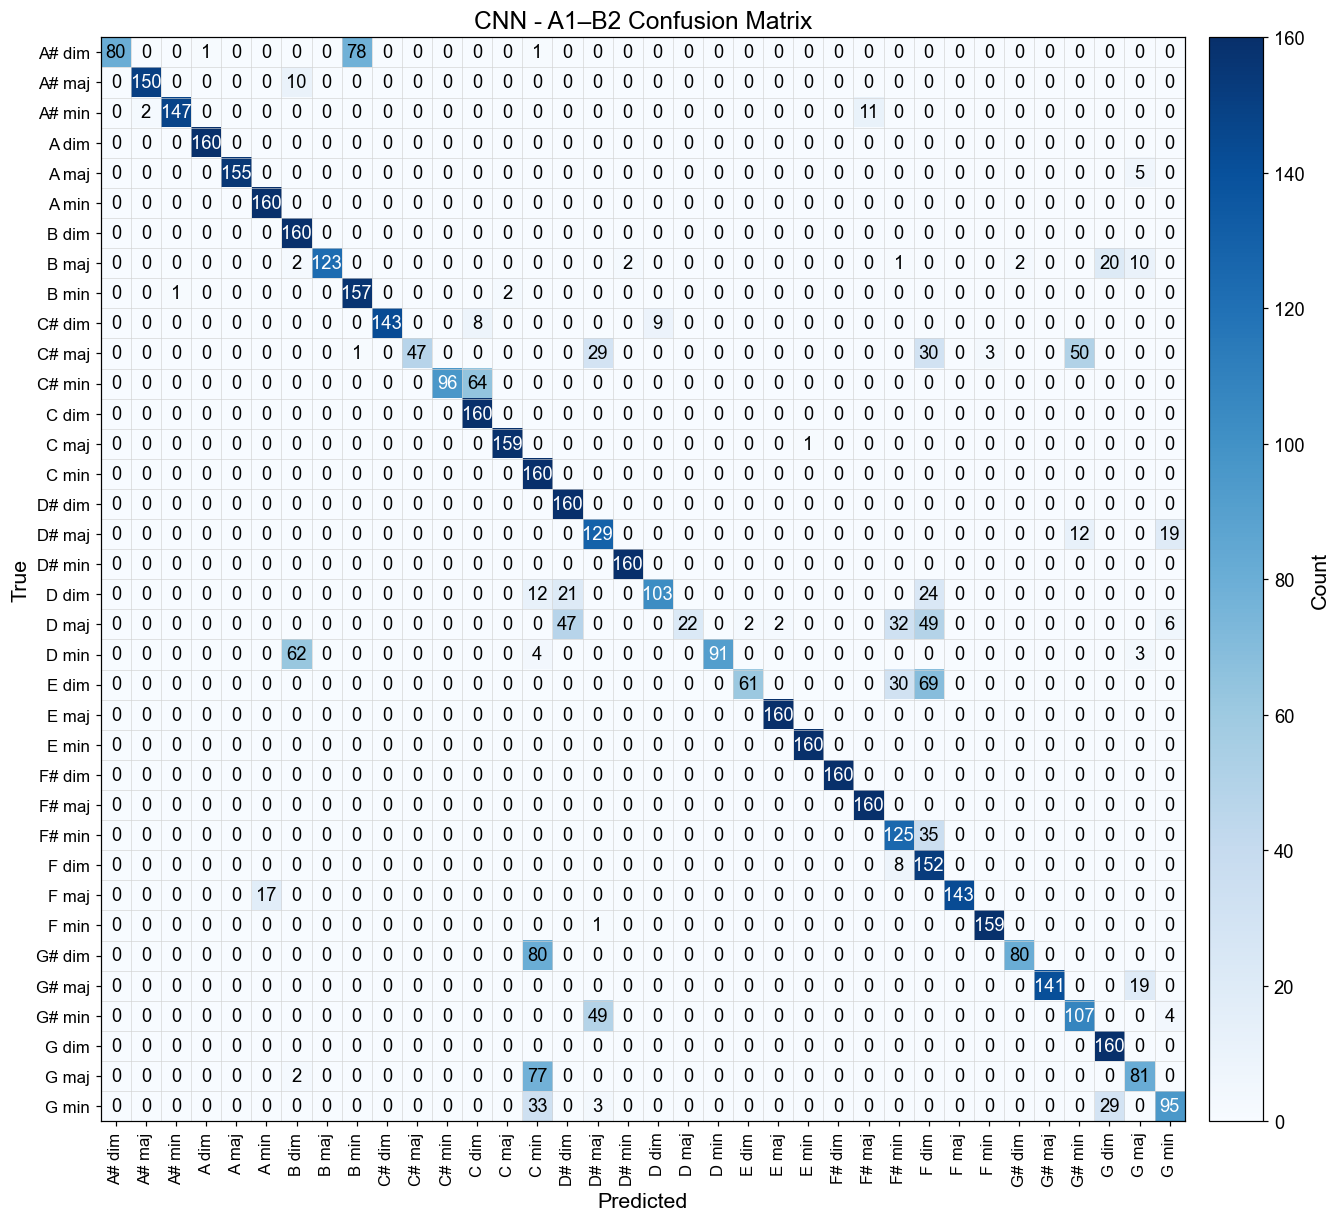

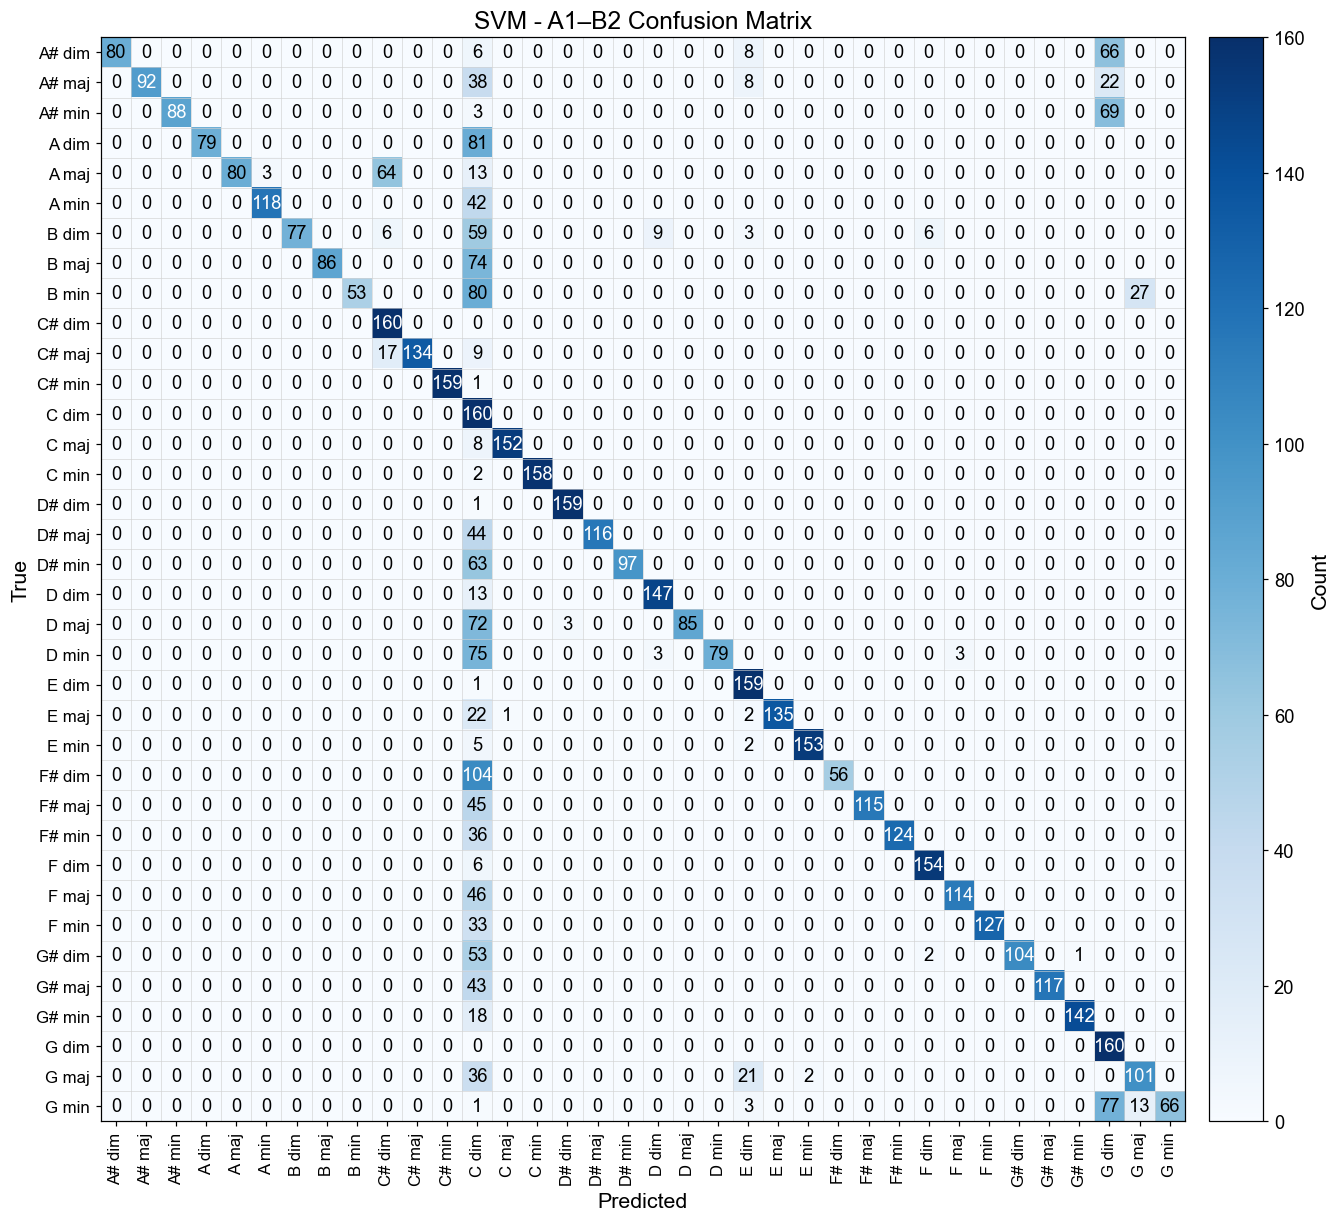

**A1–B2 combined**, seed 42

,model,accuracy,precision,recall,f1-score,n
0,CNN,0.8101,0.8697,0.8101,0.8021,5760
1,SVM,0.7267,0.9290,0.7267,0.7753,5760


In [2]:
from matplotlib.ticker import MaxNLocator

CNN_CM = CNN / "confusion"
SVM_CM = SVM / "confusion"
_QUAL = {"major": "maj", "minor": "min", "diminished": "dim"}


def pretty_class(name: str) -> str:
    body = str(name).removesuffix("_4")
    parts = body.split("_")
    if len(parts) >= 2 and parts[-1] in _QUAL:
        return f"{'_'.join(parts[:-1])} {_QUAL[parts[-1]]}"
    return body.replace("_", " ")


def load_recorded_cm(root: Path, dataset: str) -> pd.DataFrame:
    path = root / f"{dataset}_{VARIANT}_seed{SEED}.csv"
    assert path.is_file(), path
    return pd.read_csv(path, index_col=0)


def draw_cm(ax, mat, labels, title):
    vmax = max(float(mat.max()), 1.0)
    im = ax.imshow(mat, cmap="Blues", interpolation="nearest", vmin=0, vmax=vmax)
    n = len(labels)
    ax.set_xticks(np.arange(n), labels, rotation=90, fontsize=11)
    ax.set_yticks(np.arange(n), labels, fontsize=11)
    ax.set_xticks(np.arange(n) - 0.5, minor=True)
    ax.set_yticks(np.arange(n) - 0.5, minor=True)
    ax.grid(which="minor", color="0.82", linewidth=0.4)
    ax.tick_params(which="minor", bottom=False, left=False)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    thresh = 0.55 * vmax
    for i in range(n):
        for j in range(n):
            val = int(mat[i, j])
            ax.text(
                j, i, str(val), ha="center", va="center", fontsize=12,
                color="white" if val >= thresh else "black",
            )
    return im


def metrics_from_cm(mat: np.ndarray, names: list[str]):
    mat = np.asarray(mat, dtype=float)
    support = mat.sum(axis=1)
    pred_n = mat.sum(axis=0)
    tp = np.diag(mat)
    n = float(mat.sum())
    precision = np.divide(tp, pred_n, out=np.zeros_like(tp), where=pred_n > 0)
    recall = np.divide(tp, support, out=np.zeros_like(tp), where=support > 0)
    denom = precision + recall
    f1 = np.divide(2 * precision * recall, denom, out=np.zeros_like(tp), where=denom > 0)
    return {
        "accuracy": float(tp.sum() / n) if n else 0.0,
        "precision": float(np.mean(precision)),
        "recall": float(np.mean(recall)),
        "f1-score": float(np.mean(f1)),
        "n": int(n),
    }


names = list(load_recorded_cm(CNN_CM, OOD[0]).index)
labels = [pretty_class(c) for c in names]
rows = []
for model, root in (("CNN", CNN_CM), ("SVM", SVM_CM)):
    mats = [load_recorded_cm(root, ds).loc[names, names].to_numpy(dtype=float) for ds in OOD]
    mat = np.sum(mats, axis=0)
    pd.DataFrame(mat, index=names, columns=names).to_csv(
        root / f"a1-b2_{VARIANT}_seed{SEED}.csv"
    )
    rows.append({"model": model, **metrics_from_cm(mat, names)})
    fig, ax = plt.subplots(figsize=(12.4, 11.0), layout="constrained")
    im = draw_cm(ax, mat, labels, f"{model} - A1–B2 Confusion Matrix")
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02, label="Count")
    cbar.ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    plt.show()

display(Markdown("**A1–B2 combined**, seed 42"))
display(pd.DataFrame(rows).round(4))


## Overlay

Eval-only noise / room IR / mic IR on the same four recorded sets, **clean seed 42 only**. Tax is recorded accuracy minus overlay accuracy.

In [10]:
OVERLAYS = ["noise", "rir", "dir"]
OVERLAY_LABEL = {"noise": "noise", "rir": "room IR", "dir": "mic IR"}

cnn_ov = pd.read_csv(CNN / "overlay_seeds.csv")
svm_ov = pd.read_csv(SVM / "overlay_seeds.csv")
cnn_ov = cnn_ov[(cnn_ov.variant == VARIANT) & (cnn_ov.seed == SEED) & (cnn_ov.dataset.isin(OOD))].copy()
svm_ov = svm_ov[(svm_ov.variant == VARIANT) & (svm_ov.seed == SEED) & (svm_ov.dataset.isin(OOD))].copy()
assert set(OVERLAYS) <= set(cnn_ov.overlay) and set(OVERLAYS) <= set(svm_ov.overlay)


def overlay_accuracy() -> pd.DataFrame:
    rows = []
    for ds in OOD:
        row = {"evaluation": LABEL[ds]}
        row["CNN"] = float(cnn.loc[(cnn.seed == SEED) & (cnn.dataset == ds), "accuracy"].iloc[0])
        row["SVM"] = float(svm.loc[(svm.seed == SEED) & (svm.dataset == ds), "accuracy"].iloc[0])
        for ov in OVERLAYS:
            c = float(cnn_ov.loc[(cnn_ov.dataset == ds) & (cnn_ov.overlay == ov), "accuracy"].iloc[0])
            s = float(svm_ov.loc[(svm_ov.dataset == ds) & (svm_ov.overlay == ov), "accuracy"].iloc[0])
            row[f"CNN {OVERLAY_LABEL[ov]}"] = c
            row[f"SVM {OVERLAY_LABEL[ov]}"] = s
        rows.append(row)
    return pd.DataFrame(rows)


def overlay_tax() -> pd.DataFrame:
    acc = overlay_accuracy()
    rows = []
    for ov in OVERLAYS:
        lab = OVERLAY_LABEL[ov]
        for _, r in acc.iterrows():
            c_tax = r["CNN"] - r[f"CNN {lab}"]
            s_tax = r["SVM"] - r[f"SVM {lab}"]
            rows.append({
                "overlay": lab,
                "evaluation": r["evaluation"],
                "CNN tax": float(c_tax),
                "SVM tax": float(s_tax),
                "Δ tax": float(c_tax - s_tax),
            })
    return pd.DataFrame(rows)


display(Markdown("**Seed 42 accuracy** — recorded vs each overlay"))
display(overlay_accuracy().round(4))
display(Markdown("**Tax (recorded − overlay), seed 42**"))
display(overlay_tax().round(4))

**Seed 42 accuracy** — recorded vs each overlay

,evaluation,CNN,SVM,CNN noise,SVM noise,CNN room IR,SVM room IR,CNN mic IR,SVM mic IR
0,A1,0.8292,0.9931,0.6778,0.5861,0.7986,0.9347,0.7965,0.9299
1,A2,0.7111,0.6979,0.6236,0.2688,0.6618,0.8299,0.7229,0.8535
2,B1,0.9618,0.7889,0.8229,0.3243,0.8368,0.8625,0.9375,0.8562
3,B2,0.7382,0.4271,0.6403,0.1757,0.6562,0.7174,0.7382,0.7396


**Tax (recorded − overlay), seed 42**

,overlay,evaluation,CNN tax,SVM tax,Δ tax
0,noise,A1,0.1514,0.4069,-0.2556
1,noise,A2,0.0875,0.4292,-0.3417
2,noise,B1,0.1389,0.4646,-0.3257
3,noise,B2,0.0979,0.2514,-0.1535
4,room IR,A1,0.0306,0.0583,-0.0278
5,room IR,A2,0.0493,-0.1319,0.1813
6,room IR,B1,0.1250,-0.0736,0.1986
7,room IR,B2,0.0819,-0.2903,0.3722
8,mic IR,A1,0.0326,0.0632,-0.0306
9,mic IR,A2,-0.0118,-0.1556,0.1438


## Overlay tax

Points of accuracy removed by each overlay. Outlined bars, legend outside the axes.

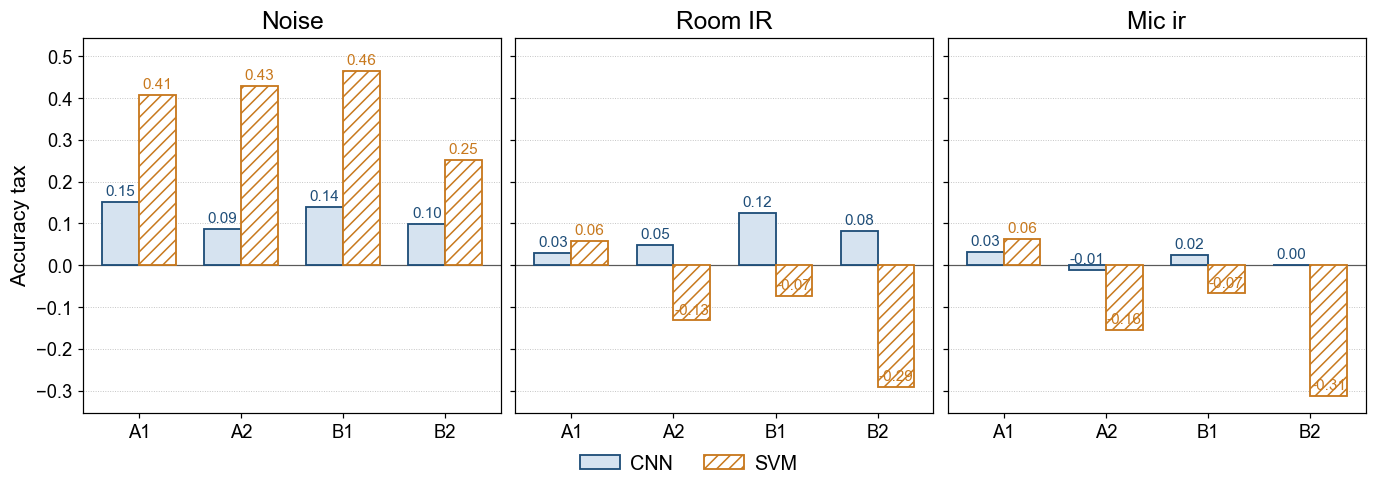

In [11]:
FILL = "#d6e3f0"
evals = [LABEL[ds] for ds in OOD]
x = np.arange(len(OOD))
width = 0.36
tax = overlay_tax()

fig, axes = plt.subplots(1, 3, figsize=(12.4, 4.4), layout="constrained", sharey=True)
for ax, ov in zip(axes, OVERLAYS):
    sub = tax.loc[tax.overlay == OVERLAY_LABEL[ov]]
    ax.bar(
        x - width / 2, sub["CNN tax"], width,
        facecolor=FILL, edgecolor=NAVY, linewidth=1.2, zorder=3,
    )
    ax.bar(
        x + width / 2, sub["SVM tax"], width,
        facecolor="white", edgecolor=ACCENT, linewidth=1.2, hatch="///", zorder=3,
    )
    ax.set_xticks(x, evals)
    ax.set_title("Room IR" if ov == "rir" else OVERLAY_LABEL[ov].capitalize())
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle=":", linewidth=0.6, color="0.75")
    ax.axhline(0, color="0.35", linewidth=0.8)
    for xi, cv, sv in zip(x, sub["CNN tax"], sub["SVM tax"]):
        ax.text(xi - width / 2, cv + 0.008, f"{cv:.2f}", ha="center", va="bottom",
                fontsize=10, color=NAVY)
        ax.text(xi + width / 2, sv + 0.008, f"{sv:.2f}", ha="center", va="bottom",
                fontsize=10, color=ACCENT)
axes[0].set_ylabel("Accuracy tax")
vals = tax[["CNN tax", "SVM tax"]].to_numpy()
axes[0].set_ylim(min(0.0, float(vals.min()) - 0.04), float(vals.max()) + 0.08)
fig.legend(
    handles=[
        plt.Rectangle((0, 0), 1, 1, facecolor=FILL, edgecolor=NAVY, linewidth=1.2),
        plt.Rectangle((0, 0), 1, 1, facecolor="white", edgecolor=ACCENT, linewidth=1.2, hatch="///"),
    ],
    labels=["CNN", "SVM"],
    loc="outside lower center", ncol=2, frameon=False,
    columnspacing=1.6, handletextpad=0.5,
)
plt.show()

## Noise classification

Clean seed 42. Macro metrics from the confusion matrices, then the matrices themselves (zeros annotated). Per-class rows are only classes with accuracy below 1.0.

In [12]:
from matplotlib.ticker import MaxNLocator

CNN_CM = CNN / "confusion"
SVM_CM = SVM / "confusion"
OVERLAY_NAME = "noise"
_QUAL = {"major": "maj", "minor": "min", "diminished": "dim"}


def pretty_class(name: str) -> str:
    body = str(name).removesuffix("_4")
    parts = body.split("_")
    if len(parts) >= 2 and parts[-1] in _QUAL:
        return f"{'_'.join(parts[:-1])} {_QUAL[parts[-1]]}"
    return body.replace("_", " ")


def load_overlay_cm(root, dataset: str) -> pd.DataFrame:
    path = root / f"{dataset}_{OVERLAY_NAME}_{VARIANT}_seed{SEED}.csv"
    assert path.is_file(), path
    return pd.read_csv(path, index_col=0)


def metrics_from_cm(mat: np.ndarray, names: list[str]):
    mat = np.asarray(mat, dtype=float)
    support = mat.sum(axis=1)
    pred_n = mat.sum(axis=0)
    tp = np.diag(mat)
    n = float(mat.sum())
    precision = np.divide(tp, pred_n, out=np.zeros_like(tp), where=pred_n > 0)
    recall = np.divide(tp, support, out=np.zeros_like(tp), where=support > 0)
    denom = precision + recall
    f1 = np.divide(2 * precision * recall, denom, out=np.zeros_like(tp), where=denom > 0)
    acc_cls = np.divide(tp, support, out=np.zeros_like(tp), where=support > 0)
    per_class = pd.DataFrame(
        {
            "class": [pretty_class(c) for c in names],
            "precision": precision,
            "recall": recall,
            "f1-score": f1,
            "accuracy": acc_cls,
            "support": support.astype(int),
        }
    )
    summary = {
        "accuracy": float(tp.sum() / n) if n else 0.0,
        "precision": float(np.mean(precision)),
        "recall": float(np.mean(recall)),
        "f1-score": float(np.mean(f1)),
    }
    return per_class, summary


def draw_cm(ax, mat, labels, title):
    vmax = max(float(mat.max()), 1.0)
    im = ax.imshow(mat, cmap="Blues", interpolation="nearest", vmin=0, vmax=vmax)
    n = len(labels)
    ax.set_xticks(np.arange(n), labels, rotation=90, fontsize=11)
    ax.set_yticks(np.arange(n), labels, fontsize=11)
    ax.set_xticks(np.arange(n) - 0.5, minor=True)
    ax.set_yticks(np.arange(n) - 0.5, minor=True)
    ax.grid(which="minor", color="0.82", linewidth=0.4)
    ax.tick_params(which="minor", bottom=False, left=False)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    thresh = 0.55 * vmax
    for i in range(n):
        for j in range(n):
            val = int(mat[i, j])
            ax.text(
                j, i, str(val), ha="center", va="center", fontsize=12,
                color="white" if val >= thresh else "black",
            )
    return im


names = list(load_overlay_cm(CNN_CM, OOD[0]).index)
rows = []
PER_CLASS = {}
for model, root in (("CNN", CNN_CM), ("SVM", SVM_CM)):
    for ds in OOD:
        cm = load_overlay_cm(root, ds).loc[names, names].to_numpy(dtype=float)
        per_class, summary = metrics_from_cm(cm, names)
        PER_CLASS[(model, ds)] = per_class
        rows.append({"model": model, "evaluation": LABEL[ds], **summary})

display(Markdown("**Noise — macro metrics**"))
display(pd.DataFrame(rows).round(4))

cols = ["class", "precision", "recall", "f1-score", "accuracy", "support"]
for model, ds in PER_CLASS:
    sub = PER_CLASS[(model, ds)]
    bad = sub.loc[sub.accuracy < 1.0, cols].sort_values(["accuracy", "class"])
    display(Markdown(f"**{model} — {LABEL[ds]} noise**, imperfect classes"))
    if bad.empty:
        display(pd.DataFrame([{"note": "every class has accuracy 1.0"}]))
    else:
        display(bad.reset_index(drop=True).round(4))

**Noise — macro metrics**

,model,evaluation,accuracy,precision,recall,f1-score
0,CNN,A1,0.6778,0.7572,0.6778,0.6777
1,CNN,A2,0.6236,0.6416,0.6236,0.5873
2,CNN,B1,0.8229,0.8522,0.8229,0.8192
3,CNN,B2,0.6403,0.6766,0.6403,0.6078
4,SVM,A1,0.5861,0.8858,0.5861,0.6402
5,SVM,A2,0.2688,0.5856,0.2688,0.2611
6,SVM,B1,0.3243,0.6798,0.3243,0.3570
7,SVM,B2,0.1757,0.3830,0.1757,0.1541


**CNN — A1 noise**, imperfect classes

,class,precision,recall,f1-score,accuracy,support
0,D maj,0.0000,0.000,0.0000,0.000,40
1,E dim,0.5000,0.025,0.0476,0.025,40
2,C# maj,0.8000,0.200,0.3200,0.200,40
3,C# dim,1.0000,0.400,0.5714,0.400,40
4,D dim,0.5517,0.400,0.4638,0.400,40
5,D# maj,0.9444,0.425,0.5862,0.425,40
6,F# min,0.1682,0.450,0.2449,0.450,40
7,A# maj,0.7692,0.500,0.6061,0.500,40
8,D min,0.9524,0.500,0.6557,0.500,40
9,B maj,0.7778,0.525,0.6269,0.525,40


**CNN — A2 noise**, imperfect classes

...

,class,precision,recall,f1-score,accuracy,support
0,A dim,0.0000,0.000,0.0000,0.000,40
1,A maj,0.0000,0.000,0.0000,0.000,40
2,A# dim,0.0000,0.000,0.0000,0.000,40
3,A# maj,0.0000,0.000,0.0000,0.000,40
4,A# min,0.0000,0.000,0.0000,0.000,40
5,B dim,0.0000,0.000,0.0000,0.000,40
6,B maj,0.0000,0.000,0.0000,0.000,40
7,B min,0.0000,0.000,0.0000,0.000,40
8,D# min,0.0000,0.000,0.0000,0.000,40
9,G maj,0.0000,0.000,0.0000,0.000,40


**SVM — B1 noise**, imperfect classes

,class,precision,recall,f1-score,accuracy,support
0,B min,0.0000,0.000,0.0000,0.000,40
1,D maj,0.0000,0.000,0.0000,0.000,40
2,D min,0.0000,0.000,0.0000,0.000,40
3,D# maj,0.0000,0.000,0.0000,0.000,40
4,D# min,0.0000,0.000,0.0000,0.000,40
5,F# dim,0.0000,0.000,0.0000,0.000,40
6,G min,0.0000,0.000,0.0000,0.000,40
7,F# min,1.0000,0.050,0.0952,0.050,40
8,F# maj,1.0000,0.075,0.1395,0.075,40
9,B dim,1.0000,0.100,0.1818,0.100,40


**SVM — B2 noise**, imperfect classes

,class,precision,recall,f1-score,accuracy,support
0,A dim,0.0000,0.000,0.0000,0.000,40
1,A maj,0.0000,0.000,0.0000,0.000,40
2,A# dim,0.0000,0.000,0.0000,0.000,40
3,A# maj,0.0000,0.000,0.0000,0.000,40
4,A# min,0.0000,0.000,0.0000,0.000,40
5,B dim,0.0000,0.000,0.0000,0.000,40
6,B maj,0.0000,0.000,0.0000,0.000,40
7,B min,0.0000,0.000,0.0000,0.000,40
8,D maj,0.0000,0.000,0.0000,0.000,40
9,D min,0.0000,0.000,0.0000,0.000,40


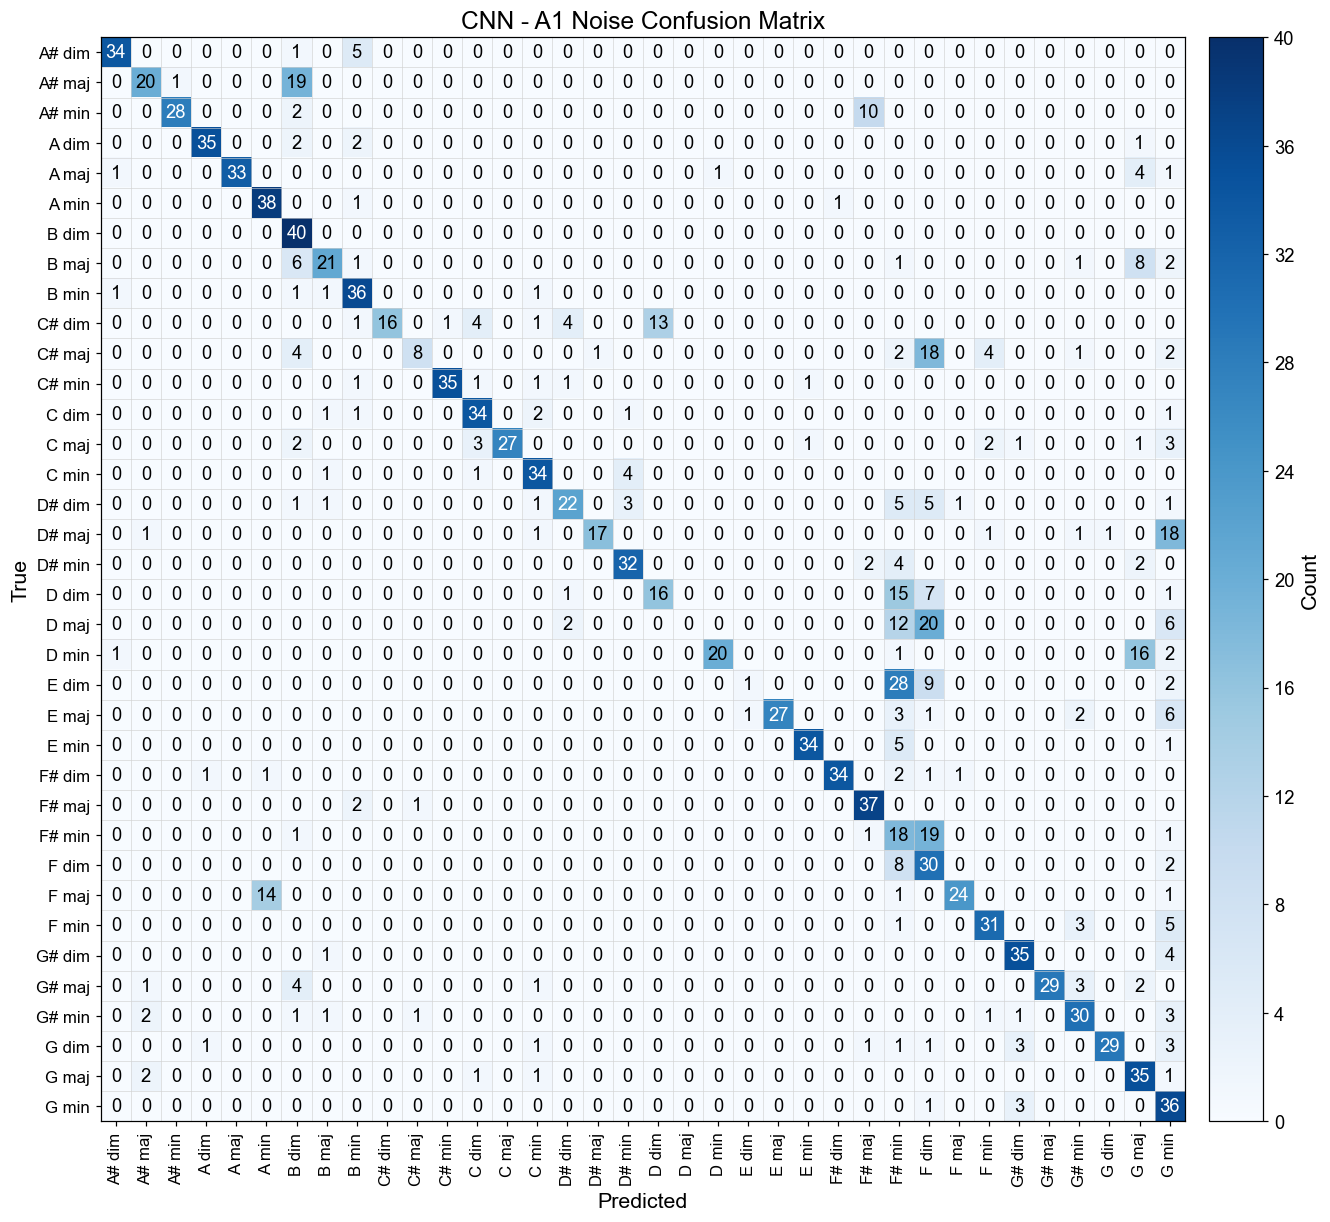

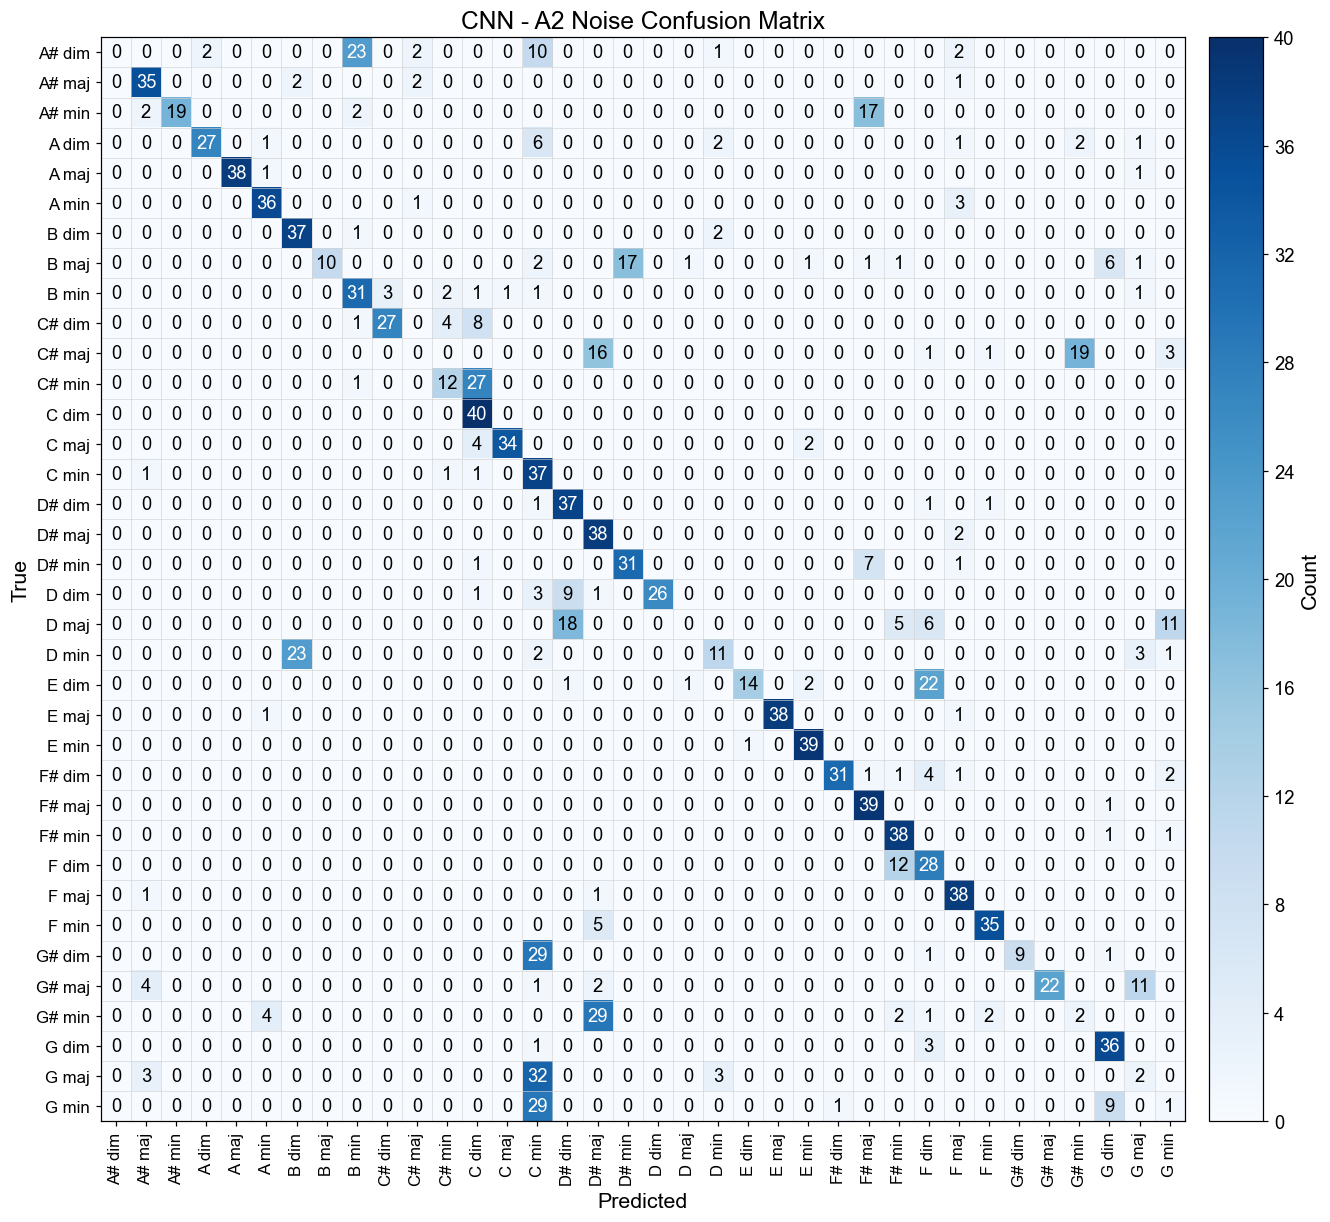

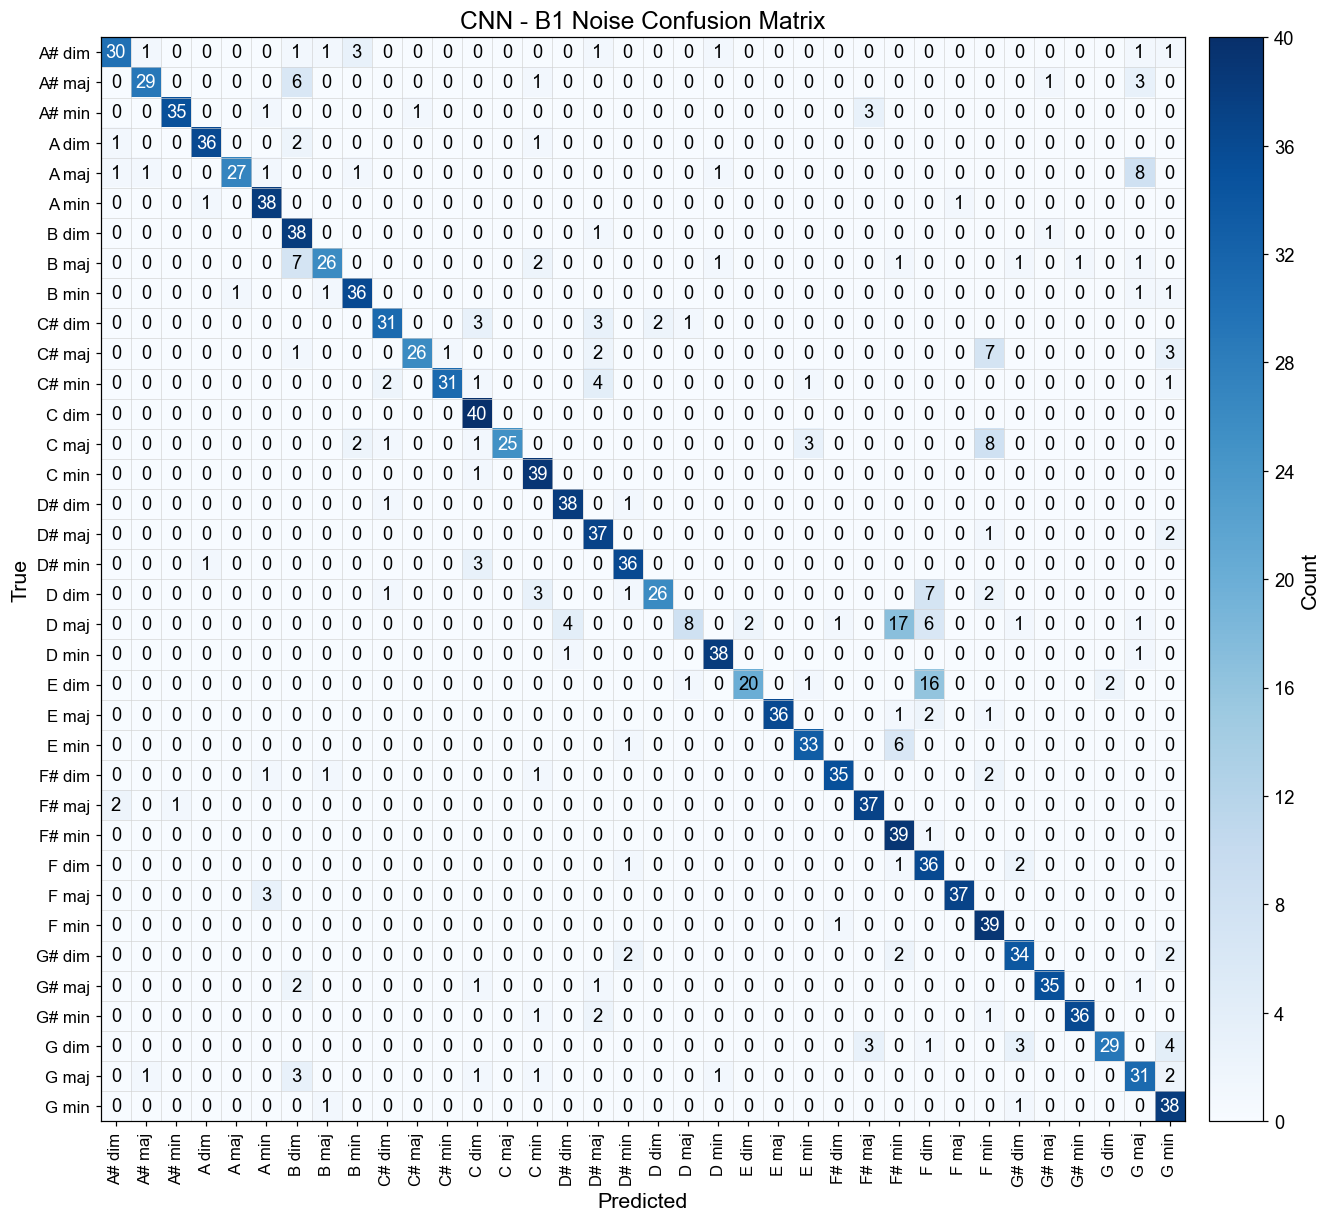

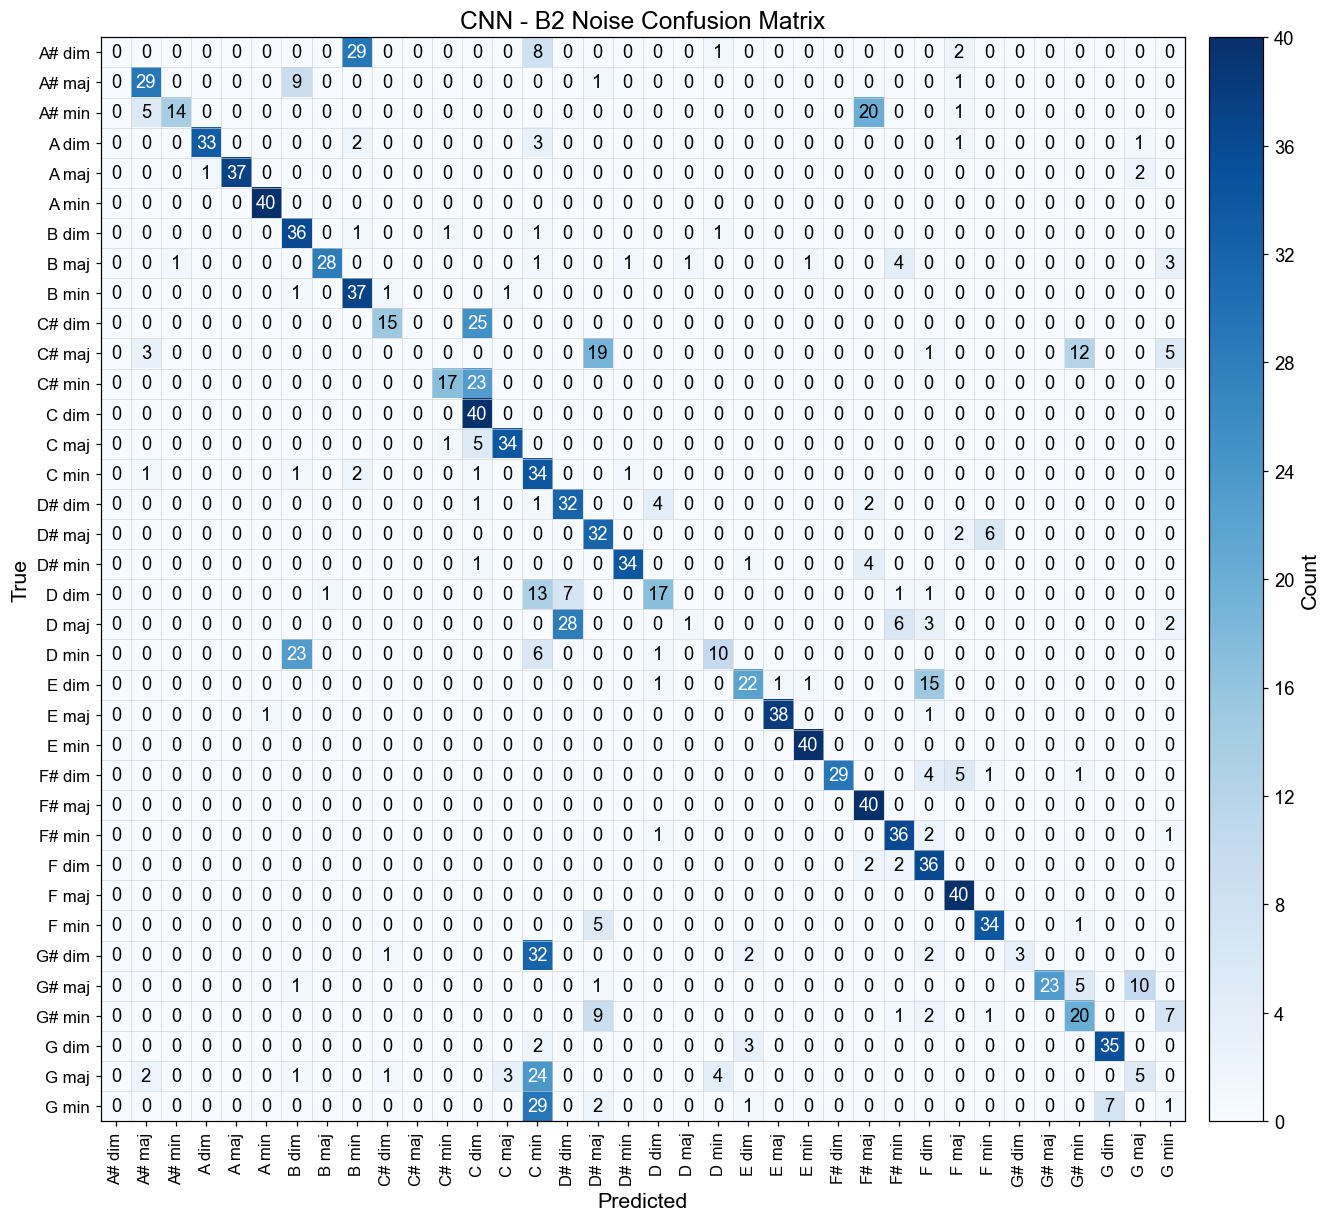

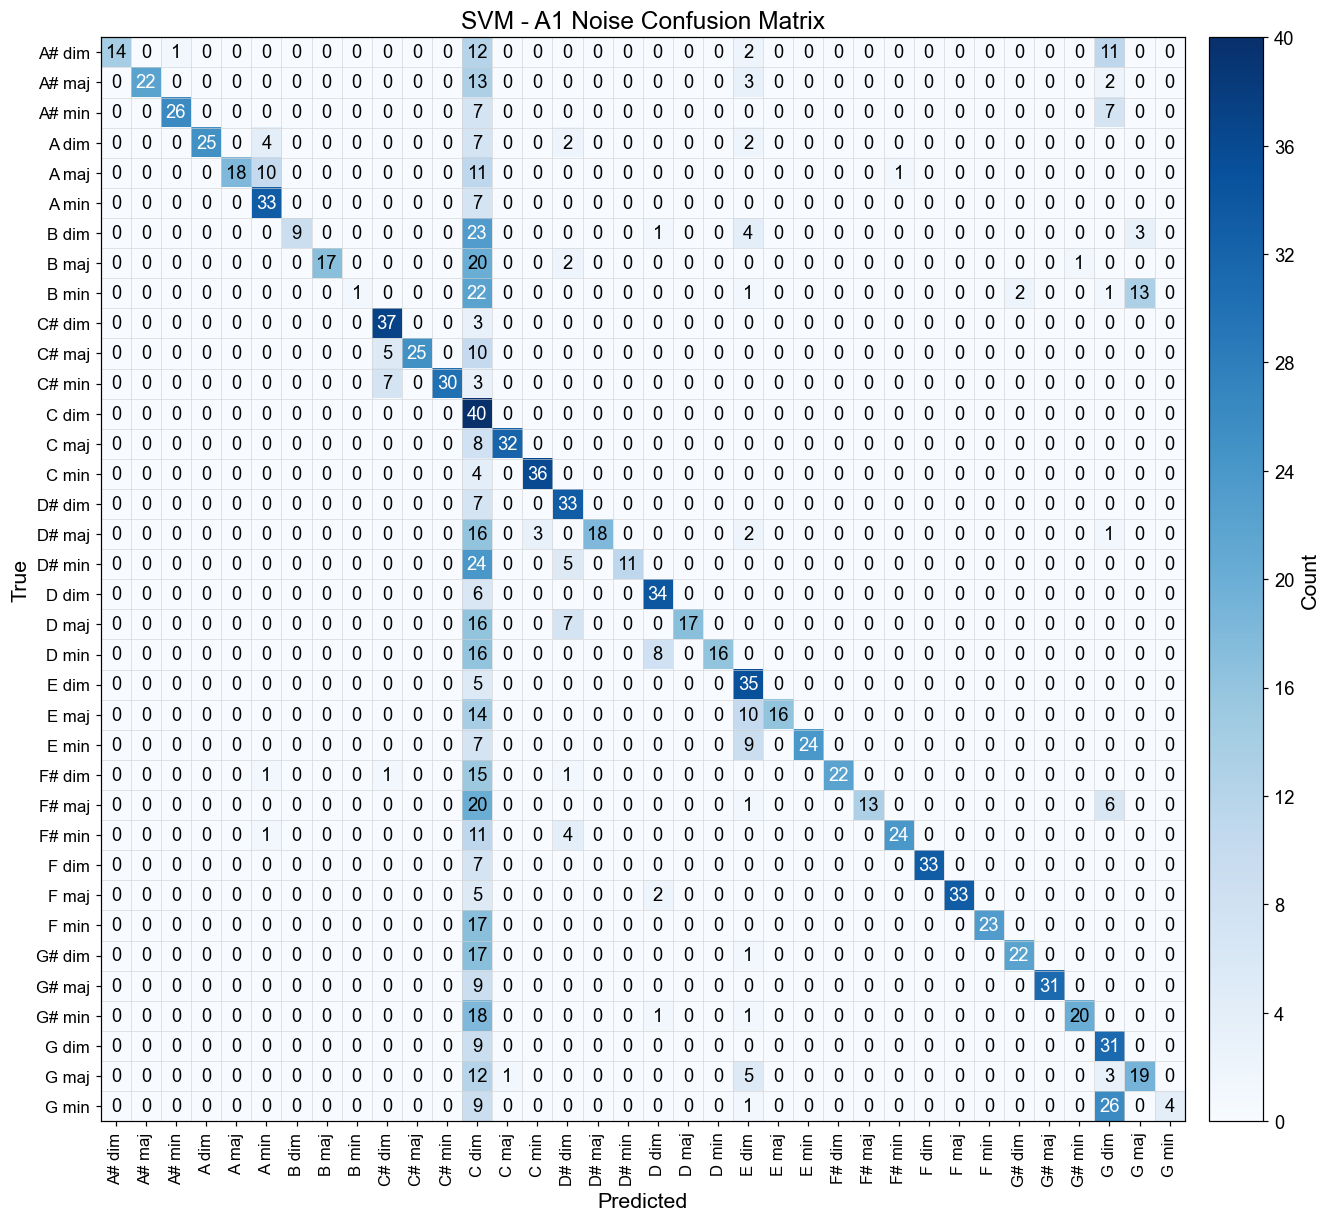

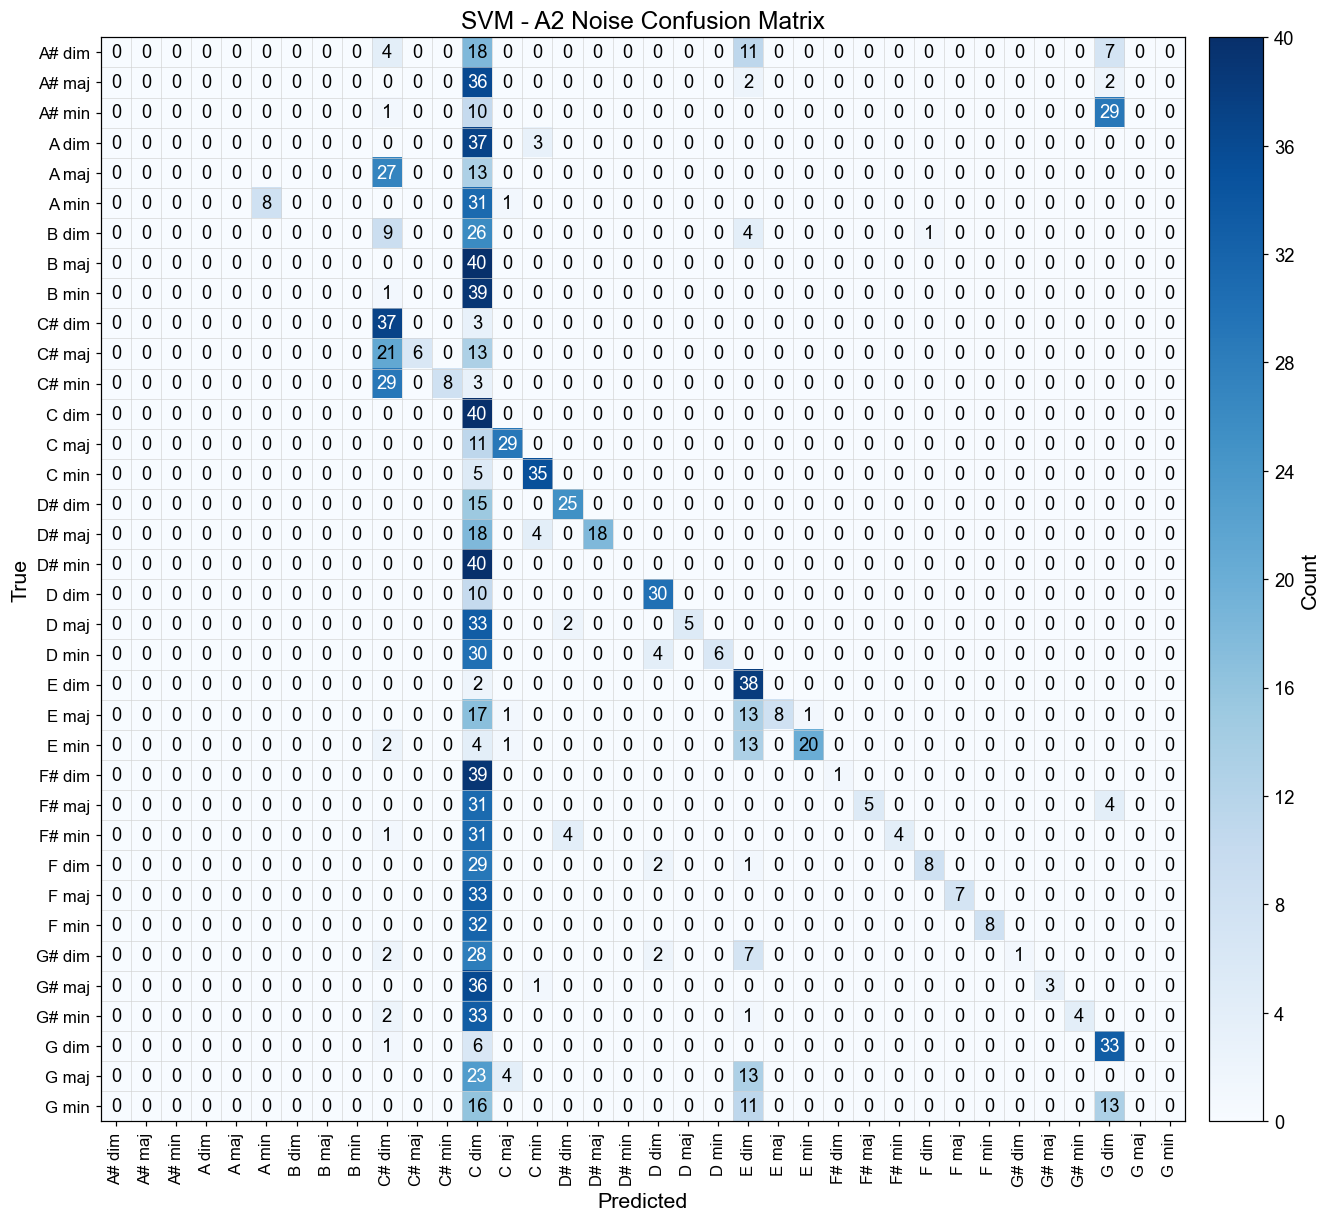

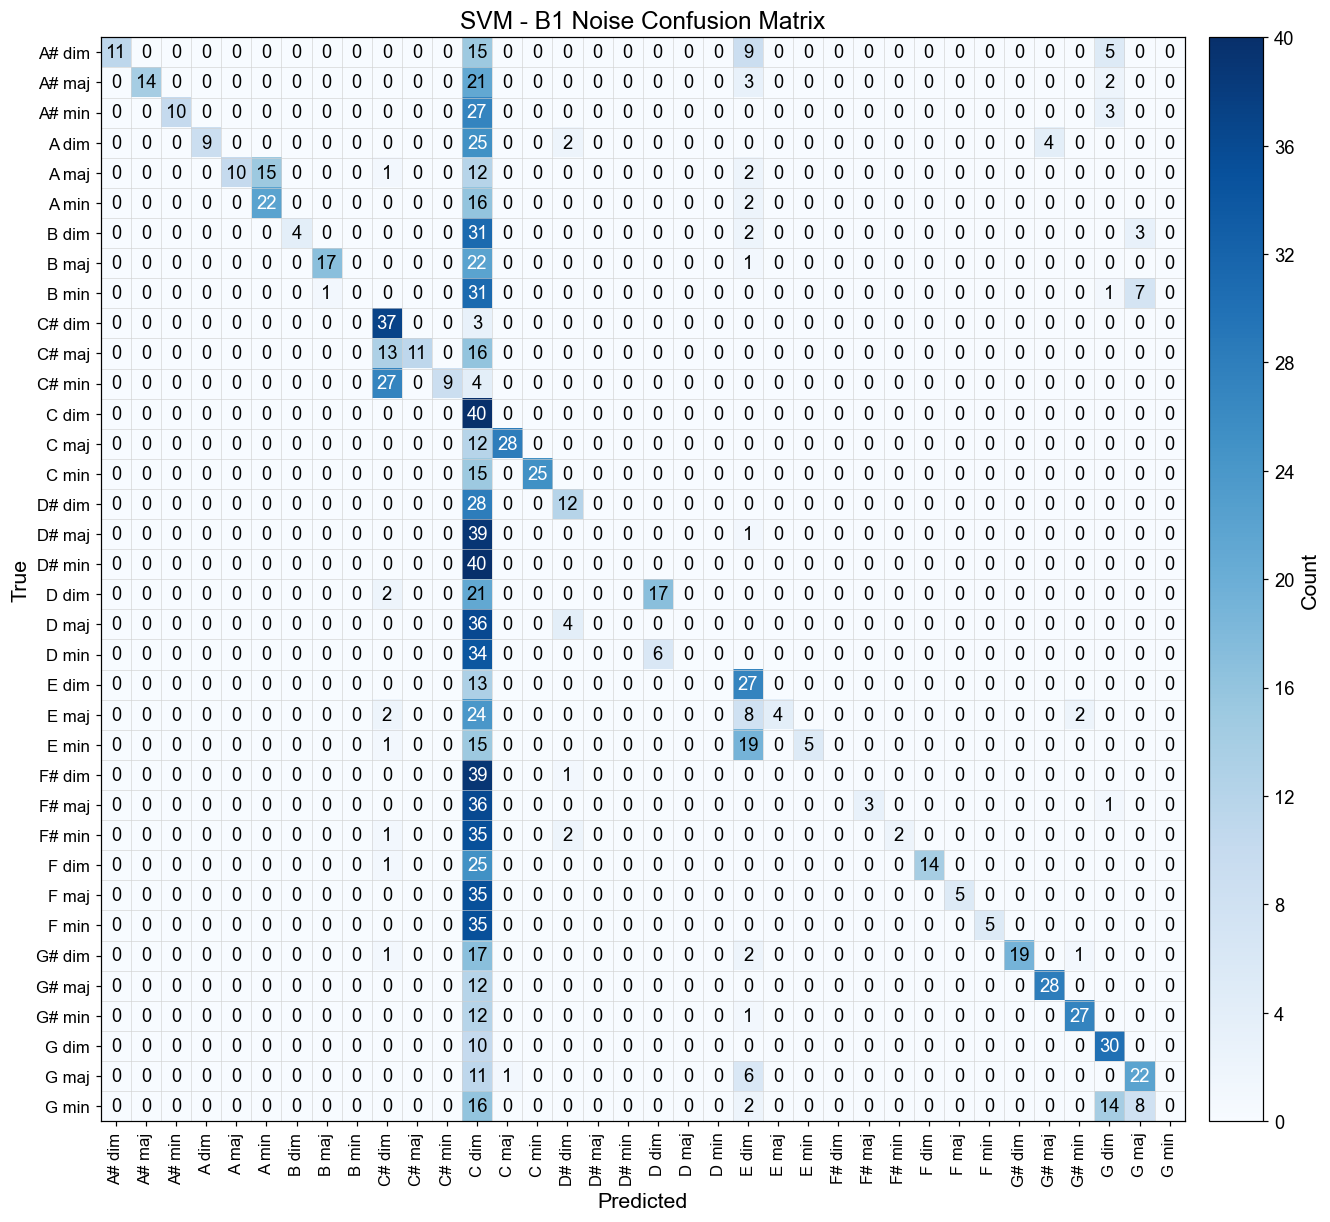

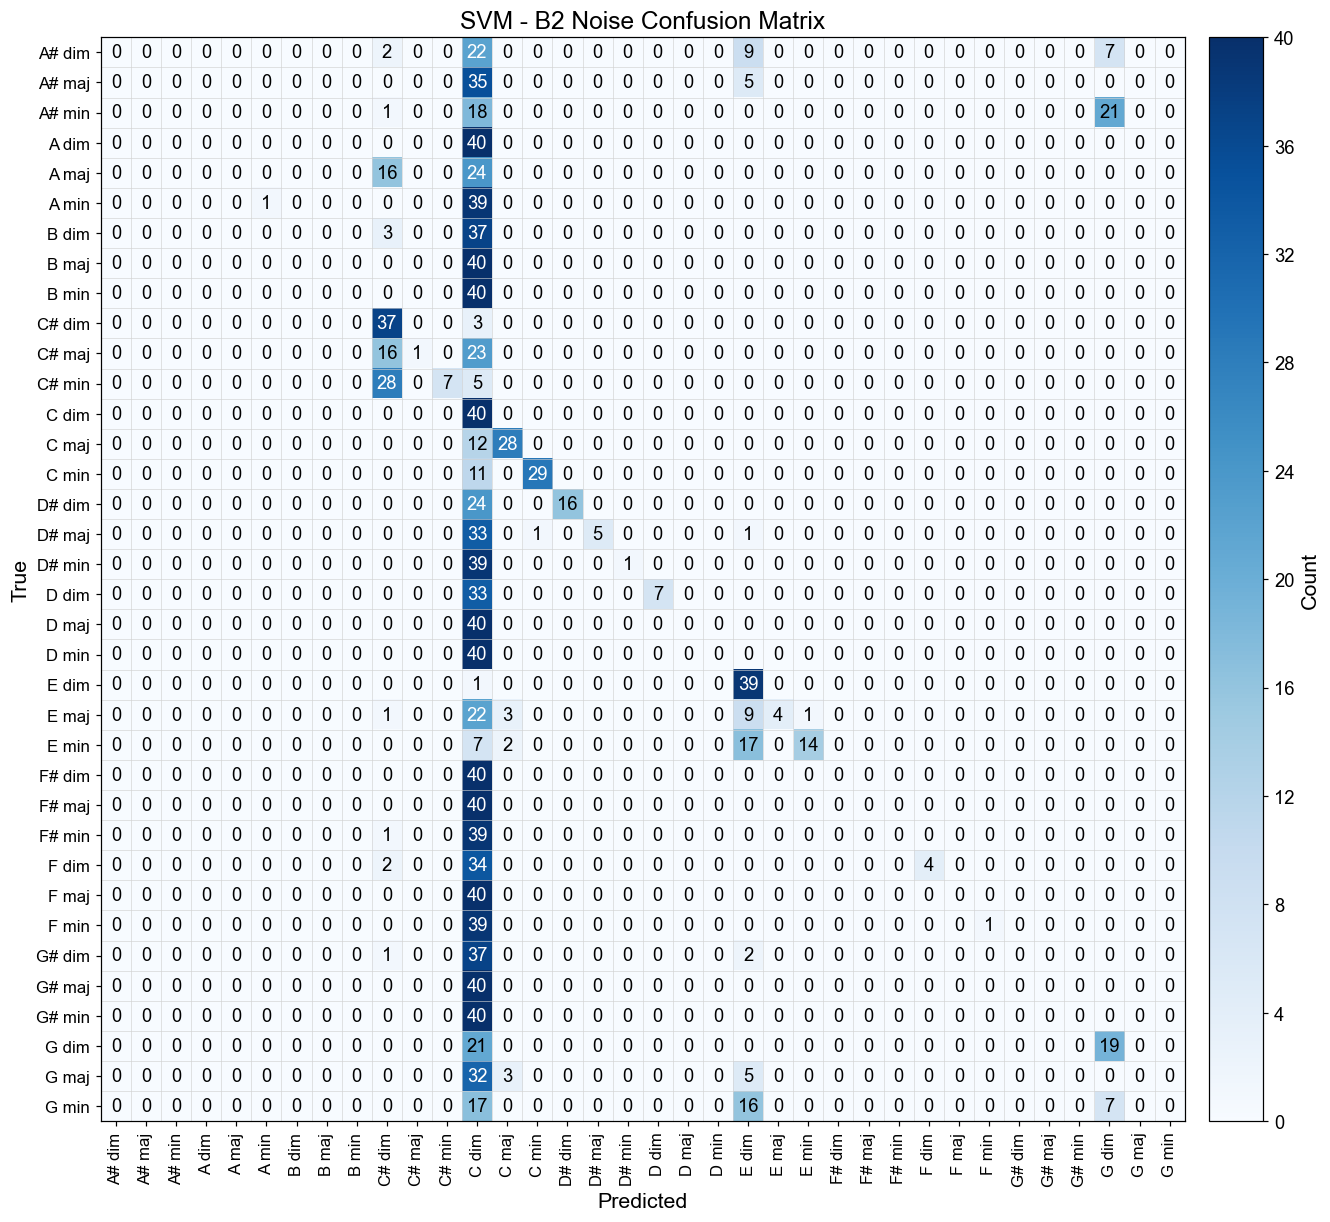

In [13]:
labels = [pretty_class(c) for c in names]
for model, root in (("CNN", CNN_CM), ("SVM", SVM_CM)):
    for ds in OOD:
        mat = load_overlay_cm(root, ds).loc[names, names].to_numpy(dtype=float)
        fig, ax = plt.subplots(figsize=(12.4, 11.0), layout="constrained")
        im = draw_cm(ax, mat, labels, f"{model} - {LABEL[ds]} Noise Confusion Matrix")
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02, label="Count")
        cbar.ax.yaxis.set_major_locator(MaxNLocator(integer=True))
        plt.show()

## Classes most affected by noise

Drop is recorded recall minus noise recall on clean seed 42. A class can already be dead on the recorded set (drop near 0, noise recall still 0); those show up in the **lowest noise recall** tables, not only in the drop ranking.

In [14]:
def load_recall(root: Path, overlay: bool) -> pd.DataFrame:
    if overlay:
        df = pd.read_csv(root / "overlay_per_class_recall.csv")
        df = df[(df.variant == VARIANT) & (df.seed == SEED) & (df.overlay == "noise")]
    else:
        df = pd.read_csv(root / "per_class_recall_seeds.csv")
        df = df[(df.variant == VARIANT) & (df.seed == SEED)]
    return df.loc[df.dataset.isin(OOD), ["dataset", "class", "recall"]]


def with_drop(base: pd.DataFrame, noise: pd.DataFrame, model: str) -> pd.DataFrame:
    m = base.merge(noise, on=["dataset", "class"], suffixes=("_rec", "_noise"))
    m["drop"] = m["recall_rec"] - m["recall_noise"]
    m["model"] = model
    m["evaluation"] = m.dataset.map(LABEL)
    m["class"] = m["class"].map(pretty_class)
    return m


cnn_drop = with_drop(
    load_recall(CNN, False), load_recall(CNN, True), "CNN"
)
svm_drop = with_drop(
    load_recall(SVM, False), load_recall(SVM, True), "SVM"
)


def top_drop(df: pd.DataFrame, n: int = 8) -> pd.DataFrame:
    return (
        df.sort_values(["drop", "recall_noise", "class"], ascending=[False, True, True])
        .head(n)[["class", "recall_rec", "recall_noise", "drop"]]
        .reset_index(drop=True)
    )


for ds in OOD:
    display(Markdown(f"**{LABEL[ds]}** — largest recall drop"))
    left = top_drop(cnn_drop.loc[cnn_drop.dataset == ds]).add_prefix("CNN ")
    right = top_drop(svm_drop.loc[svm_drop.dataset == ds]).add_prefix("SVM ")
    display(pd.concat([left, right], axis=1).round(3))


def overall(df: pd.DataFrame) -> pd.DataFrame:
    g = (
        df.groupby("class", as_index=False)
        .agg(
            recorded=("recall_rec", "mean"),
            noise=("recall_noise", "mean"),
            drop=("drop", "mean"),
            sets_hit=("drop", lambda s: int((s > 0).sum())),
        )
        .sort_values(["drop", "noise", "class"], ascending=[False, True, True])
    )
    return g.reset_index(drop=True)


cnn_all = overall(cnn_drop)
svm_all = overall(svm_drop)
display(Markdown("**Overall** — mean drop across A1–B2"))
display(pd.concat(
    [
        cnn_all.head(10).add_prefix("CNN "),
        svm_all.head(10).add_prefix("SVM "),
    ],
    axis=1,
).round(3))

display(Markdown("**Overall** — lowest noise recall (includes classes already dead on recorded)"))
cnn_low = cnn_all.sort_values(["noise", "class"]).head(10).reset_index(drop=True)
svm_low = svm_all.sort_values(["noise", "class"]).head(10).reset_index(drop=True)
display(pd.concat(
    [
        cnn_low[["class", "recorded", "noise", "drop"]].add_prefix("CNN "),
        svm_low[["class", "recorded", "noise", "drop"]].add_prefix("SVM "),
    ],
    axis=1,
).round(3))

def quality_row(df: pd.DataFrame, model: str) -> pd.DataFrame:
    q = df["class"].str.split().str[-1]
    out = df.assign(quality=q).groupby("quality", as_index=False).agg(
        recorded=("recall_rec", "mean"),
        noise=("recall_noise", "mean"),
        drop=("drop", "mean"),
    )
    out.insert(0, "model", model)
    return out.sort_values("quality")

display(Markdown("**Quality** — mean drop"))
display(pd.concat([quality_row(cnn_drop, "CNN"), quality_row(svm_drop, "SVM")], ignore_index=True).round(3))

**A1** — largest recall drop

,CNN class,CNN recall_rec,CNN recall_noise,CNN drop,SVM class,SVM recall_rec,SVM recall_noise,SVM drop
0,D# dim,1.000,0.550,0.450,B min,0.975,0.025,0.950
1,D min,0.925,0.500,0.425,G min,0.925,0.100,0.825
2,C# dim,0.800,0.400,0.400,B dim,1.000,0.225,0.775
3,C maj,1.000,0.675,0.325,D# min,1.000,0.275,0.725
4,E maj,1.000,0.675,0.325,F# maj,1.000,0.325,0.675
5,A# min,1.000,0.700,0.300,A# dim,1.000,0.350,0.650
6,A# maj,0.775,0.500,0.275,E maj,0.975,0.400,0.575
7,G dim,1.000,0.725,0.275,B maj,1.000,0.425,0.575


**A2** — largest recall drop

,CNN class,CNN recall_rec,CNN recall_noise,CNN drop,SVM class,SVM recall_rec,SVM recall_noise,SVM drop
0,A# min,0.900,0.475,0.425,D# min,0.975,0.000,0.975
1,A dim,1.000,0.675,0.325,F# min,1.000,0.100,0.900
2,C# dim,0.975,0.675,0.300,G# min,1.000,0.100,0.900
3,G# maj,0.800,0.550,0.250,D maj,0.975,0.125,0.850
4,B min,1.000,0.775,0.225,D min,1.000,0.150,0.850
5,D# min,1.000,0.775,0.225,G# maj,0.900,0.075,0.825
6,F# dim,1.000,0.775,0.225,C# min,1.000,0.200,0.800
7,G min,0.225,0.025,0.200,F dim,1.000,0.200,0.800


**B1** — largest recall drop

...

,CNN class,CNN recorded,CNN noise,CNN drop,CNN sets_hit,SVM class,SVM recorded,SVM noise,SVM drop,SVM sets_hit
0,C# dim,0.894,0.556,0.337,4,C# min,0.994,0.338,0.656,4
1,A# min,0.919,0.600,0.319,4,E maj,0.844,0.200,0.644,4
2,C maj,0.994,0.750,0.244,4,F dim,0.962,0.369,0.594,4
3,B maj,0.769,0.531,0.238,4,F# maj,0.719,0.131,0.588,4
4,A# maj,0.938,0.706,0.231,4,F# min,0.775,0.188,0.588,4
5,G# maj,0.881,0.681,0.200,4,C# maj,0.838,0.269,0.569,4
6,F# dim,1.000,0.806,0.194,4,G# min,0.888,0.319,0.569,4
7,G dim,1.000,0.806,0.194,4,F min,0.794,0.231,0.562,4
8,D# dim,1.000,0.806,0.194,4,E min,0.956,0.394,0.562,4
9,A dim,1.000,0.819,0.181,4,D# min,0.606,0.075,0.531,3


**Overall** — lowest noise recall (includes classes already dead on recorded)

,CNN class,CNN recorded,CNN noise,CNN drop,SVM class,SVM recorded,SVM noise,SVM drop
0,D maj,0.138,0.056,0.081,B min,0.331,0.006,0.325
1,C# maj,0.294,0.213,0.081,G min,0.412,0.025,0.388
2,E dim,0.381,0.356,0.025,D# min,0.606,0.075,0.531
3,A# dim,0.500,0.400,0.100,B dim,0.481,0.081,0.400
4,G maj,0.506,0.456,0.050,F# maj,0.719,0.131,0.588
5,G min,0.594,0.475,0.119,D maj,0.531,0.138,0.394
6,D min,0.569,0.494,0.075,D min,0.494,0.138,0.356
7,G# dim,0.500,0.506,-0.006,F# dim,0.350,0.144,0.206
8,B maj,0.769,0.531,0.238,A# dim,0.500,0.156,0.344
9,D dim,0.644,0.531,0.112,A maj,0.500,0.175,0.325


**Quality** — mean drop

,model,quality,recorded,noise,drop
0,CNN,dim,0.822,0.692,0.130
1,CNN,maj,0.766,0.642,0.123
2,CNN,min,0.842,0.739,0.103
3,SVM,dim,0.779,0.484,0.294
4,SVM,maj,0.691,0.272,0.419
5,SVM,min,0.710,0.260,0.451


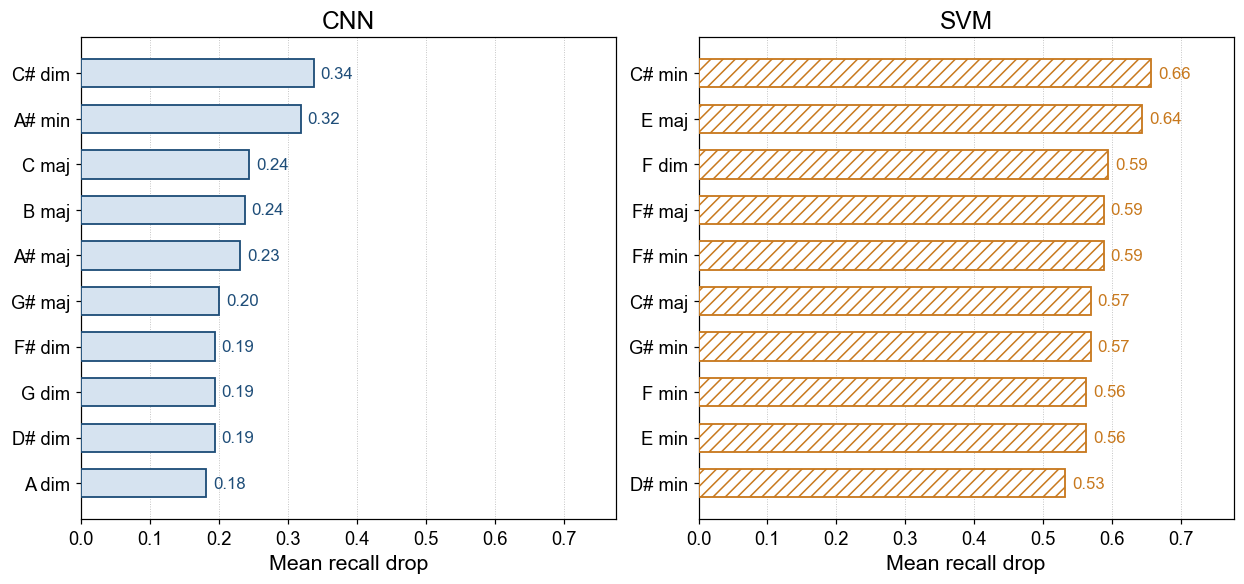

In [15]:
FILL = "#d6e3f0"
n_show = 10
cnn_top = cnn_all.head(n_show).iloc[::-1]
svm_top = svm_all.head(n_show).iloc[::-1]

fig, axes = plt.subplots(1, 2, figsize=(11.2, 5.2), layout="constrained", sharex=True)
for ax, top, title, edge in (
    (axes[0], cnn_top, "CNN", NAVY),
    (axes[1], svm_top, "SVM", ACCENT),
):
    y = np.arange(len(top))
    ax.barh(
        y, top["drop"], height=0.62,
        facecolor=FILL if title == "CNN" else "white",
        edgecolor=edge, linewidth=1.2, hatch="" if title == "CNN" else "///",
        zorder=3,
    )
    ax.set_yticks(y, top["class"])
    ax.set_xlabel("Mean recall drop")
    ax.set_title(title)
    ax.set_axisbelow(True)
    ax.xaxis.grid(True, linestyle=":", linewidth=0.6, color="0.75")
    for yi, v in zip(y, top["drop"]):
        ax.text(v + 0.01, yi, f"{v:.2f}", va="center", fontsize=11, color=edge)
    ax.set_xlim(0, max(cnn_all["drop"].max(), svm_all["drop"].max()) + 0.12)
plt.show()

CNN’s noise tax is a **few specific chords**, not a quality wipe. Across A1–B2 the largest mean drops are **C♯ dim (0.34)**, **A♯ min (0.32)**, then C maj / B maj / A♯ maj (~0.23–0.24). Those five lose recall on all four sets. **D maj** is the worst *absolute* noise recall (0.06) because it was already dead on A2/B2; the drop ranking hides that.

SVM’s tax is **broader and heavier**. Mean drops of 0.53–0.66 hit **C♯ min, E maj, F dim, F♯ min, F♯ maj**. Lowest noise recall is **B min (0.01)** and **G min (0.03)** — classes that were fine on recorded A1 and then collapse. By quality, SVM minors drop 0.45 and majors 0.42; CNN stays 0.10–0.13 on every quality.

Per set: CNN’s top hits rotate (D♯ dim / D min on A1, A♯ min on A2, D maj / C maj / D dim on B1, C♯ dim / A♯ min on B2). SVM repeatedly kills **minors and F♯/B-family** chords (B min, G min, F♯ min/maj, C♯ min).